In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
import os
import nibabel as nib
import logging
import mri_utils

# torch.set_num_threads(24) # Anzahl deiner zugewiesenen Kerne
# torch.set_num_interop_threads(24)
print(torch.cuda.is_available())

True


In [2]:
# Hyperparameter
AMOUNT_VOLUMES_TO_LOAD = 5

## Import Datasets, Add Degraded and Ground Truth

In [3]:
import os
import nibabel as nib
import numpy as np
from tqdm import tqdm 
import tracemalloc

tracemalloc.start()  # Tracke RAM-Nutzung

# Konfiguration
data_folder = "/srv/fMRI-data/"
output_dir = "./processed_data"  # Verzeichnis für zwischengespeicherte Daten
os.makedirs(output_dir, exist_ok=True)


# Liste aller NIfTI-Dateien
nii_files = sorted([
    f for f in os.listdir(data_folder)
    if f.endswith(".nii.gz")
])

print(f"Found {len(nii_files)} NIfTI files in {data_folder}")

# Optional: Nur die ersten 5 Volumes verarbeiten, um die Funktion zu testen
nii_files = nii_files[:AMOUNT_VOLUMES_TO_LOAD]  

# Funktion zum Laden und Degradieren eines Volumes
def process_volume(file_path):
    img = nib.load(file_path)
    volume = np.asanyarray(img.dataobj, dtype=np.float32)

    # Degraded-Daten erstellen
    gt_vol, degraded_vol = mri_utils.generate_dataset_list(
        [volume],
        keep_fraction=0.6,
        noise_min=0.01,
        noise_max=0.05
    )

    return gt_vol[0], degraded_vol[0]

# Daten als NumPy-Arrays speichern (oder direkt verarbeiten)
gt = []
degraded = []

snapshot = tracemalloc.take_snapshot()

for file in tqdm(nii_files, desc="Processing files"):
    file_path = os.path.join(data_folder, file)

    # Volume laden und GT sowie degraded Daten erstellen
    gt_vol, degraded_vol = process_volume(file_path)
    gt.append(gt_vol)
    degraded.append(degraded_vol)

print("Daten erfolgreich verarbeitet und gespeichert.")

print(type(gt))
print(type(degraded))

snapshot = tracemalloc.take_snapshot()
tracemalloc.stop()

print( "\n RAM-Nutzung analysieren...")
# Analysiere die Top-Speicherverbraucher
for stat in snapshot.statistics('lineno')[:5]:  # Zeige die Top 5
    print(stat)

Found 28 NIfTI files in /srv/fMRI-data/


Processing files:   0%|          | 0/5 [00:00<?, ?it/s]

Processing volume 1/1


Processing files:  20%|██        | 1/5 [00:27<01:50, 27.62s/it]


Dataset generation complete.
Processing volume 1/1


...


Dataset generation complete.
Processing volume 1/1


Processing files:  80%|████████  | 4/5 [01:47<00:28, 28.38s/it]


Dataset generation complete.
Processing volume 1/1


Processing files: 100%|██████████| 5/5 [02:01<00:00, 24.20s/it]


Dataset generation complete.
Daten erfolgreich verarbeitet und gespeichert.
<class 'list'>
<class 'list'>

 RAM-Nutzung analysieren...
/home/seyfried/.venv/lib/python3.12/site-packages/numpy/_core/numeric.py:161: size=5592 MiB, count=15, average=373 MiB
/home/seyfried/.venv/lib/python3.12/site-packages/nibabel/volumeutils.py:463: size=5592 MiB, count=10, average=559 MiB
<frozen importlib._bootstrap>:488: size=552 KiB, count=2283, average=248 B
<frozen importlib._bootstrap_external>:753: size=129 KiB, count=522, average=253 B
/home/seyfried/.venv/lib/python3.12/site-packages/numpy/_core/numeric.py:1330: size=83.7 KiB, count=1531, average=56 B


## Erstelle Chunks

In [ ]:
# from skimage.util import view_as_blocks

# def split_3d(volume, patch_size=64):
#     # Schneidet das Volume in nicht-überlappende Blöcke (Voraussetzung: Dimensionen sind durch patch_size teilbar)

#     x, y, z = volume.shape
#     crop_x = (x // patch_size) * patch_size
#     crop_y = (y // patch_size) * patch_size
#     crop_z = (z // patch_size) * patch_size
    
#     trimmed_volume = volume[:crop_x, :crop_y, :crop_z]
    
#     # Erstellt einen RAM-schonenden "View" ohne Datenkopie!
#     blocks = view_as_blocks(trimmed_volume, (patch_size, patch_size, patch_size))
#     # Umformen in (Anzahl_Patches, patch_size, patch_size, patch_size)
#     return blocks.reshape(-1, patch_size, patch_size, patch_size)



In [4]:
#also anstatt neue patches in einer neuen variable zu erzeugen,
#  speichert man nur die koordinaten, und wenn man einen patch nutzen will, greift man auf die originaldaten mit den koordinaten zu
def generate_patch_coordinates(volume_shape, patch_size=64, stride=28):

    x, y, z = volume_shape

    coords = []

    for i in range(0, x - patch_size + 1, stride):
        for j in range(0, y - patch_size + 1, stride):
            for k in range(0, z - patch_size + 1, stride):

                coords.append((i, j, k))

    return coords

In [5]:
volume_gt = gt[0]
volume_dg = degraded[0]

print(volume_gt.shape)
print(volume_dg.shape)

patch_size = 64
stride = 28

coords = generate_patch_coordinates(
    volume_gt.shape[:3],
    patch_size,
    stride
)

patches_per_timestep = len(coords)

num_timesteps = volume_gt.shape[3]

print("patches_per_timestep:", patches_per_timestep)
print("num_timesteps:", num_timesteps)

(128, 128, 93, 219)
(128, 128, 93, 219)
patches_per_timestep: 18
num_timesteps: 219


### Ground Truth

### Degraded

### Visualize same Ground Truth and Degraded image

(64, 64)


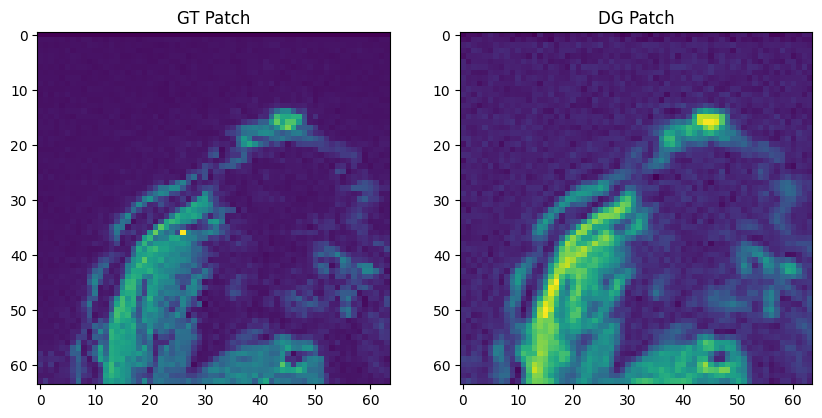

In [6]:
x, y, z = coords[0]

img_gt = volume_gt[x:x+patch_size, y:y+patch_size, z, 0]
img_dg = volume_dg[x:x+patch_size, y:y+patch_size, z, 0]
print(img_gt.shape)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_gt)
plt.title("GT Patch")

plt.subplot(1,2,2)
plt.imshow(img_dg)
plt.title("DG Patch")

plt.show()

### Dataset

In [7]:
class VolumeDataset(Dataset):

    def __init__(self, volume_gt, volume_dg, coords, patch_size=28):

        self.volume_gt = volume_gt.astype(np.float32)
        self.volume_dg = volume_dg.astype(np.float32)

        self.coords = coords
        self.patch_size = patch_size

        self.num_timesteps = volume_gt.shape[3]
        self.patches_per_timestep = len(coords)

    def __len__(self):
        return (self.num_timesteps * self.patches_per_timestep)

    def __getitem__(self, idx):

        timestep = idx // self.patches_per_timestep
        patch_idx = idx % self.patches_per_timestep

        x, y, z = self.coords[patch_idx]

        p = self.patch_size

        # Get one patch by coordinates and normalize
        gt_patch = self.volume_gt[x:x+p, y:y+p, z:z+p, timestep]
        dg_patch = self.volume_dg[x:x+p, y:y+p, z:z+p, timestep]

        gt_patch = ( gt_patch - gt_patch.min() ) / ( gt_patch.max() - gt_patch.min() + 1e-8)
        dg_patch = ( dg_patch - dg_patch.min() ) / ( dg_patch.max() - dg_patch.min() + 1e-8)

        gt_patch = torch.from_numpy(gt_patch[None, ...])
        dg_patch = torch.from_numpy(dg_patch[None, ...])

        return dg_patch, gt_patch

### Normalisierung

### Dataset + Dataloader

In [ ]:
# TODO: Nur ein Volume vorerst im Dataset !!
dataset = VolumeDataset(
    volume_gt,
    volume_dg,
    coords,
    patch_size=28
)

dataloader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=False, # da später rekonstruktion zu ganzem bild!
    num_workers=0,
    pin_memory=False
)

# garbage collector
import gc
gc.collect()

###  3D CNN

In [ ]:
import torch.nn as nn
import torch.nn.functional as F


class ConvBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.bn = nn.BatchNorm3d(channels)
        self.conv = nn.Conv3d(
            channels, channels,
            kernel_size=3,
            padding=1
        )

    def forward(self, x):
        x = self.bn(x)
        x = self.conv(x)
        x = F.relu(x)
        return x


class CNN3D(nn.Module):
    def __init__(self):
        super().__init__()

        # First block: input -> 64 channels
        self.first = nn.Sequential(
            nn.Conv3d(1, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )

        # 7 repeated blocks
        self.blocks = nn.Sequential(
            *[ConvBlock(64) for _ in range(7)]
        )

        # Last block (no activation)
        self.last = nn.Sequential(
            nn.BatchNorm3d(64),
            nn.Conv3d(64, 1, kernel_size=3, padding=1)
        )

    def forward(self, x):
        x = self.first(x)
        x = self.blocks(x)
        x = self.last(x)
        return x

In [ ]:
# loss function
criterion = nn.MSELoss()

In [ ]:
#optimizer
model = CNN3D()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [ ]:
#training setup
num_epochs = 20

In [ ]:
#training

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Starting epochs...")
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for dg, gt in dataloader:
    
        dg = dg.to(device)
        gt = gt.to(device)

        optimizer.zero_grad()

        output = model(dg)

        loss = criterion(output, gt)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

Modell speichern und laden - wichtig für NLM

In [ ]:
# torch.save(model.state_dict(), 'model_weights.pth')

In [ ]:
model = CNN3D() 

# 2. Gewichte laden
model.load_state_dict(torch.load('model_weights.pth'))


### Non-Local-Means filter (NLM)

In [ ]:
from skimage.restoration import denoise_nl_means, estimate_sigma

def nlm_3d(cnn_output, h=0.8, patch_size=5, patch_distance=6):
    """
    cnn_output: (1, X, Y, Z) or (X, Y, Z)
    returns refined volume
    """

    if cnn_output.ndim == 4:
        cnn_output = cnn_output[0]

    X, Y, Z = cnn_output.shape
    result = np.zeros_like(cnn_output)

    for z in range(Z):
        slice_img = cnn_output[:, :, z]

        sigma_est = np.mean(estimate_sigma(slice_img, channel_axis=None))

        nlm = denoise_nl_means(
            slice_img,
            h=h * sigma_est,
            fast_mode=True,
            patch_size=patch_size,
            patch_distance=patch_distance,
            channel_axis=None
        )

        result[:, :, z] = nlm

    return result

In [ ]:
# CNN + NLM Denoising
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

model.eval()

dg_batch0, gt_batch0 = next(iter(dataloader))

with torch.no_grad():

    # Eingabe auf Device verschieben
    dg_batch0 = dg_batch0.to(device)

    # CNN Vorhersage
    cnn_out = model(dg_batch0)

    # Tensor -> NumPy
    cnn_out_np = cnn_out.detach().cpu().numpy()

    # NLM auf jede Prediction anwenden
    refined_outputs = []

    for i in range(cnn_out_np.shape[0]):

        refined = nlm_3d(
            cnn_out_np[i],
            h=0.8,
            patch_size=5,
            patch_distance=6
        )

        refined_outputs.append(refined)

    refined_outputs = np.array(refined_outputs)

# Beispielslice anzeigen
gt_slice = gt_batch0[0, 0, :, :, 0].cpu().numpy()

cnn_slice = cnn_out_np[0, 0, :, :, 0]

nlm_slice = refined_outputs[0, :, :, 0]

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(gt_slice)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cnn_slice)
plt.title("CNN Output")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(nlm_slice)
plt.title("CNN + NLM")
plt.axis("off")

plt.tight_layout()
plt.show()

### Visualisierungen

siehe data prep: noise-only differences, resolution-only differences (difference map)

In [ ]:
# GT vs. Prediction + Difference Map (Prediction, GT)
# noise only
dg_batch0, gt_batch0 = next(iter(dataloader))


gt_batch0 = gt_batch0[0, 0, :, :, 0]
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(gt_batch0)
plt.title("Ground Truth (GT)")
plt.axis('off')

pred_dg = model(dg_batch0).detach().cpu()

pred_dg = pred_dg[0, 0, :, :, 0]
plt.subplot(1, 3, 2)
plt.imshow(pred_dg)
plt.title("Pred")
plt.axis('off')


difference_map = gt_batch0 - pred_dg
plt.subplot(1, 3, 3)
plt.imshow(difference_map)
plt.title("Difference GT-Pred")
plt.axis('off')


plt.tight_layout()
plt.show()
 # Visualisierung sieht schlecht aus, Modell ist ja auch noch nicht trainiert zum jetzigen Stand
 # Dataloader enthält Shuffle=True, deswegen immer zufälliger neuer 1. Batch

# SNR Berechnung auf Prediction und Ground Truth

In [ ]:
from skimage.metrics import peak_signal_noise_ratio


gt_batch0 = gt_batch0.numpy()
pred_dg = pred_dg.numpy()

dg_batch0 = dg_batch0[0, 0, :, :, 0].numpy()

psnr_gt_dg = peak_signal_noise_ratio(gt_batch0, dg_batch0, data_range=gt_batch0.max() - gt_batch0.min())
print(f"PSNR of {psnr_gt_dg}")

psnr_gt_pred = peak_signal_noise_ratio(gt_batch0, pred_dg, data_range=gt_batch0.max() - gt_batch0.min())
print(f"PSNR of {psnr_gt_pred}")

## Rekonstruktion 3D Bilder

In [ ]:
# def rebuild_3d(patches, original_shape, patch_size=28, stride=28):
#     """
#     patches: Die extrahierten Patches für EINEN Zeitschritt (N, 12, 12, 12)
#     original_shape: Die Form des ursprünglichen 3D-Bildes (X, Y, Z)
#     """
#     x, y, z = original_shape
#     # Leeres Volumen mit Nullen erstellen
#     reconstructed = np.zeros((x, y, z), dtype=patches.dtype)
    
#     patch_idx = 0
    
#     # Die gleichen Schleifen wie beim Splitten durchlaufen
#     for i in range(0, x - patch_size + 1, stride):
#         for j in range(0, y - patch_size + 1, stride):
#             for k in range(0, z - patch_size + 1, stride):
                
#                 # Den aktuellen Patch an die richtige Stelle setzen
#                 reconstructed[i:i+patch_size, 
#                               j:j+patch_size, 
#                               k:k+patch_size] = patches[patch_idx]
                
#                 patch_idx += 1
                
#     return reconstructed

def rebuild_3d(patches, target_shape):
    x, y, z = target_shape
    reconstructed = np.zeros((x, y, z))
    
    # Dynamisch die Patch-Größe aus dem ersten Patch bestimmen (hier 64)
    patch_size = patches.shape[1] 
    
    # Wenn du beim Splitten keinen Überlapp verwendet hast, ist der Stride gleich der Patch-Größe
    stride = patch_size 
    
    patch_idx = 0
    for i in range(0, x - patch_size + 1, stride):
        for j in range(0, y - patch_size + 1, stride):
            for k in range(0, z - patch_size + 1, stride):
                
                # Sicherstellen, dass wir nicht über das Array-Ende hinauslesen
                if patch_idx < len(patches):
                    reconstructed[i:i+patch_size, 
                                  j:j+patch_size, 
                                  k:k+patch_size] = patches[patch_idx]
                    patch_idx += 1
                    
    return reconstructed

Für Ground Truth:

Für Degraded:

In [ ]:
# garbage collector
import gc
gc.collect()

# 1. Bestimme, wie viele Patches ein einzelnes 3D-Volumen hat
# (Das ist all_chunks_gt.shape[1] aus deinem vorherigen Code)
patches_per_timestep = all_chunks_dg.shape[1]
print(patches_per_timestep)

num_timesteps = all_chunks_dg.shape[0]

print(num_timesteps)

original_3d_shape = (128, 128, 84)

print(original_3d_shape)


# Angenommen 'denoised_data' sind deine bearbeiteten Patches in Shape (Gesamt, 1, 12, 12, 12)
# Wir entfernen zuerst die Kanal-Dimension
denoised_data = data_gt.squeeze(1) 
print(denoised_data.shape)
reconstructed_volume_4d = []

for t in range(num_timesteps):
    # Extrahiere die Patches für diesen spezifischen Zeitschritt
    start = t * patches_per_timestep
    end = start + patches_per_timestep
    current_time_patches = denoised_data[start:end]
    
    # Rekonstruiere das 3D-Bild
    img_3d = rebuild_3d(current_time_patches, original_3d_shape)
    reconstructed_volume_4d.append(img_3d)

# Wieder zu 4D zusammenfügen (X, Y, Z, Time)
final_volume_dg = np.stack(reconstructed_volume_4d, axis=-1)

print(final_volume_dg.shape) # Sollte wieder der Ursprungsform entsprechen


Für Prediction (CNN):

In [ ]:
# #Zunächst Patches erzeugen:
# # garbage collector
# import gc
# gc.collect()


# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model.eval()
# model.to(device)

# predicted_patches = []

# with torch.no_grad():

#     for i in range(len(data_dg)):

#         # numpy -> tensor
#         patch = torch.tensor(
#             data_dg[i],
#             dtype=torch.float32
#         )

#         # Nur Batch-Dimension hinzufügen
#         # Shape:
#         # (1, 1, 28, 28, 28)

#         patch = patch.unsqueeze(0).to(device)

#         # prediction
#         pred = model(patch)

#         # zurück zu numpy
#         pred_np = pred.squeeze().cpu().numpy()

#         predicted_patches.append(pred_np)

# predicted_patches = np.array(predicted_patches)

# print("CNN predicted patches shape:")
# print(predicted_patches.shape)

# Beschleunigte Vorhersage mit Mini-Batches
from torch.utils.data import TensorDataset, DataLoader

# Konvertiere das gesamte numpy-Array auf einmal in einen Tensor
# (Kanal-Dimension beibehalten, falls das Modell sie erwartet, z.B. Shape: N, 1, 64, 64, 64)
dataset = TensorDataset(torch.tensor(data_dg, dtype=torch.float32))
dataloader = DataLoader(dataset, batch_size=32, shuffle=False) # Batch-Size an VRAM anpassen

model.eval()
model.to(device)

predicted_list = []

with torch.no_grad():
    for batch in dataloader:
        inputs = batch[0].to(device)
        preds = model(inputs)
        
        # Zurück zu Numpy und in Liste speichern
        predicted_list.append(preds.cpu().numpy())

# Alle Batches wieder zusammenfügen
predicted_patches = np.concatenate(predicted_list, axis=0)
# Falls nötig, die Batch-/Kanal-Dimensionen analog zu vorher anpassen (squeeze)
predicted_patches = predicted_patches.squeeze(1) 

print("CNN predicted patches shape:", predicted_patches.shape)


In [ ]:
# Rekonstruktion der CNN Predictions

# Anzahl Patches pro Zeitschritt
patches_per_timestep = all_chunks_dg.shape[1]

print("patches_per_timestep:", patches_per_timestep)

# Anzahl Timesteps
num_timesteps = all_chunks_dg.shape[0]

print("num_timesteps:", num_timesteps)

# Ursprüngliche 3D Form
original_3d_shape = (128, 128, 84)

print("original_3d_shape:", original_3d_shape)

reconstructed_volume_4d = []

for t in range(num_timesteps):

    # Richtige Patches dieses Timesteps holen
    start = t * patches_per_timestep
    end = start + patches_per_timestep

    current_time_patches = predicted_patches[start:end]

    # 3D rekonstruieren
    img_3d = rebuild_3d(
        current_time_patches,
        original_3d_shape
    )

    reconstructed_volume_4d.append(img_3d)

# Wieder 4D erzeugen
final_volume_pr = np.stack(reconstructed_volume_4d, axis=-1)

print("final_volume_pr shape:")
print(final_volume_pr.shape)

Für CNN+NLM:

In [ ]:
# NLM auf CNN Predictions anwenden

nlm_patches = []

for i in range(len(predicted_patches)):

    patch = predicted_patches[i]

    refined = nlm_3d(
        patch,
        h=0.8,
        patch_size=5,
        patch_distance=6
    )

    nlm_patches.append(refined)

nlm_patches = np.array(nlm_patches)

print("NLM patches shape:")
print(nlm_patches.shape)



In [ ]:
# Rekonstruktion der NLM Patches

# Anzahl Patches pro Zeitschritt
patches_per_timestep = all_chunks_dg.shape[1]

print("patches_per_timestep:", patches_per_timestep)

# Anzahl Timesteps
num_timesteps = all_chunks_dg.shape[0]

print("num_timesteps:", num_timesteps)

# Ursprüngliche 3D Form
original_3d_shape = (128, 128, 84)

print("original_3d_shape:", original_3d_shape)

reconstructed_volume_4d = []

for t in range(num_timesteps):

    # Richtige Patches dieses Timesteps holen
    start = t * patches_per_timestep
    end = start + patches_per_timestep

    current_time_patches = nlm_patches[start:end]

    # 3D rekonstruieren
    img_3d = rebuild_3d(
        current_time_patches,
        original_3d_shape
    )

    reconstructed_volume_4d.append(img_3d)

# Wieder 4D erzeugen
final_volume_nlm = np.stack(reconstructed_volume_4d, axis=-1)

print("final_volume_nlm shape:")
print(final_volume_nlm.shape)

In [ ]:
# garbage collector
import gc
gc.collect()

# Rekonstruktion der GT Patches

# 1. Bestimme, wie viele Patches ein einzelnes 3D-Volumen hat
# (Das ist all_chunks_gt.shape[1] aus deinem vorherigen Code)
patches_per_timestep = all_chunks_gt.shape[1]
print(patches_per_timestep)

num_timesteps = all_chunks_gt.shape[0]

print(num_timesteps)

original_3d_shape = (128, 128, 84)

print(original_3d_shape)


# Angenommen 'denoised_data' sind deine bearbeiteten Patches in Shape (Gesamt, 1, 12, 12, 12)
# Wir entfernen zuerst die Kanal-Dimension
denoised_data = data_gt.squeeze(1) 
print(denoised_data.shape)
reconstructed_volume_4d = []

for t in range(num_timesteps):
    # Extrahiere die Patches für diesen spezifischen Zeitschritt
    start = t * patches_per_timestep
    end = start + patches_per_timestep
    current_time_patches = denoised_data[start:end]
    
    # Rekonstruiere das 3D-Bild
    img_3d = rebuild_3d(current_time_patches, original_3d_shape)
    reconstructed_volume_4d.append(img_3d)

# Wieder zu 4D zusammenfügen (X, Y, Z, Time)
final_volume_gt = np.stack(reconstructed_volume_4d, axis=-1)

print(final_volume_gt.shape) # Sollte wieder der Ursprungsform entsprechen



In [ ]:
visualization_gt = final_volume_gt[:, :, 0, 0]
# visualization_dg = dg[:, :, 0, 0]
visualization_pr = final_volume_pr[:, :, 0, 0]
# visualization_nlm = final_volume_nlm[:, :, 0, 0]

plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
plt.imshow(np.rot90(visualization_gt), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

# plt.subplot(2, 3, 2)
# plt.imshow(np.rot90(visualization_dg), cmap="gray")
# plt.title("degraded")
# plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(np.rot90(visualization_pr), cmap="gray")
plt.title("prediction")
plt.axis("off")

# plt.subplot(2, 3, 3)
# plt.imshow(np.rot90(visualization_nlm), cmap="gray")
# plt.title("cnn + nlm")
# plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(np.rot90(visualization_gt - visualization_pr), cmap='bwr')
plt.title("Difference map GT - PR")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

# plt.subplot(2, 3, 5)
# plt.imshow(np.rot90(visualization_gt - visualization_nlm), cmap='bwr')
# plt.title("Difference map GT - NLM")
# plt.axis("off")
# plt.colorbar(fraction=0.046, pad=0.04)

# plt.subplot(2, 3, 4)
# plt.imshow(np.rot90(show_kspace(gt_slice), 1), cmap="gray")
# plt.title("Ground Truth k-space")
# plt.axis("off")

# plt.subplot(2, 3, 5)
# plt.imshow(np.rot90(show_kspace(lowres_slice), 1), cmap="gray")
# plt.title("Low-res k-space")
# plt.axis("off")

# plt.subplot(2, 3, 6)
# plt.imshow(np.rot90(show_kspace(gt_slice) - show_kspace(lowres_slice), 1), cmap="gray")
# plt.title("Difference k-space")
# plt.axis("off")
# plt.colorbar(fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
